--- Advanced XGBoost Performance Summary ---
RMSE: 1949.96 MW
MAE:  1455.48 MW
MAPE: 4.57%
--------------------------------------------


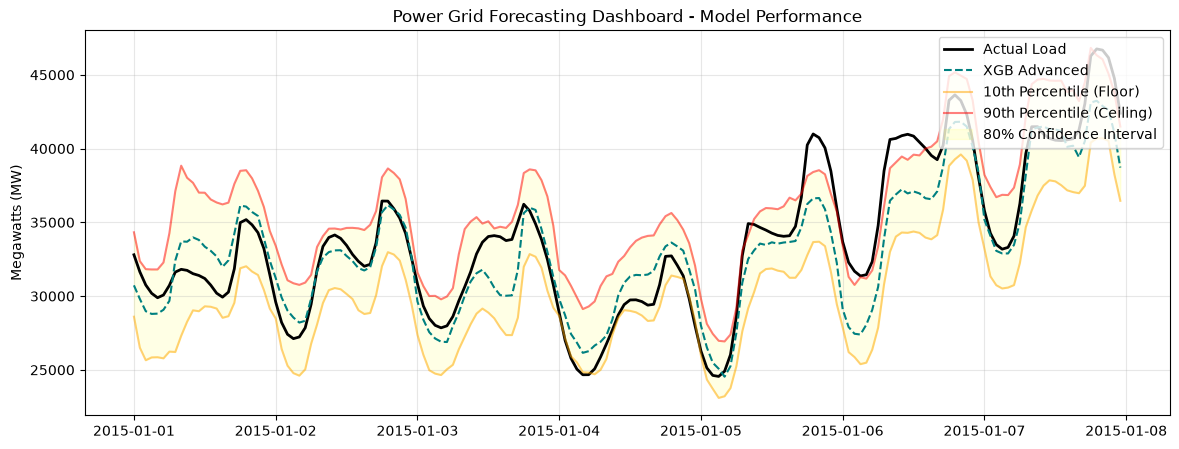


[Notice] 'reg_adv' isn't active in this notebook kernel's RAM.
To view the SHAP beeswarm chart, run this specific try/except block at the bottom of 02_model_training.ipynb!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Load the data safely from disk
test_adv = pd.read_csv('test_with_predictions.csv', index_col=0, parse_dates=True)
TARGET = 'PJME_MW'

# 2. Calculate and Display Metrics for the saved Advanced XGBoost model
rmse_val = root_mean_squared_error(test_adv[TARGET], test_adv['xgb_advanced_pred'])
mae_val = mean_absolute_error(test_adv[TARGET], test_adv['xgb_advanced_pred'])
mape_val = mean_absolute_percentage_error(test_adv[TARGET], test_adv['xgb_advanced_pred']) * 100

print("--- Advanced XGBoost Performance Summary ---")
print(f"RMSE: {rmse_val:.2f} MW")
print(f"MAE:  {mae_val:.2f} MW")
print(f"MAPE: {mape_val:.2f}%")
print("--------------------------------------------")

# 3. Plot the 1-Week Diagnostic Zoom Chart
plt.figure(figsize=(14, 5))
zoom_df = test_adv.loc['2015-01-01':'2015-01-07'] 
plt.plot(zoom_df.index, zoom_df[TARGET], label='Actual Load', color='black', linewidth=2)
plt.plot(zoom_df.index, zoom_df['xgb_advanced_pred'], label='XGB Advanced', color='teal', linestyle='--')
plt.plot(zoom_df.index, zoom_df['lower_bound'], label='10th Percentile (Floor)', color='orange', alpha=0.5)
plt.plot(zoom_df.index, zoom_df['upper_bound'], label='90th Percentile (Ceiling)', color='red', alpha=0.5)
plt.fill_between(zoom_df.index, zoom_df['lower_bound'], zoom_df['upper_bound'], color='yellow', alpha=0.1, label='80% Confidence Interval')
plt.title('Power Grid Forecasting Dashboard - Model Performance')
plt.ylabel('Megawatts (MW)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Phase 10: Explainable AI SHAP Breakdown
# Reconstruct feature columns to pass to the explainer
FEATURES = ['lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
X_test_adv = test_adv[FEATURES]

try:
    # Use the active trained model instance to extract tree calculations
    explainer = shap.TreeExplainer(reg_adv)
    X_test_sample = X_test_adv.sample(500, random_state=42)
    shap_values = explainer(X_test_sample)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_sample, show=False)
    plt.title('SHAP Feature Impact Breakdown (Phase 10)', fontsize=14)
    plt.tight_layout()
    plt.show()
except NameError:
    print("\n[Notice] 'reg_adv' isn't active in this notebook kernel's RAM.")
    print("To view the SHAP beeswarm chart, run this specific try/except block at the bottom of 02_model_training.ipynb!")

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Manually define the features array used during model training
FEATURES_LIST = [
    'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 
    'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear'
]

# 2. Map features to their importance weights and sort them
importance_df = pd.DataFrame({
    'Feature': FEATURES_LIST,
    'Importance': reg_adv.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 3. Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Relative Importance Score')
plt.title('Advanced XGBoost Feature Importance Breakdown')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'reg_adv' is not defined

--- Advanced XGBoost Performance Summary ---
RMSE: 1949.96 MW
MAE:  1455.48 MW
MAPE: 4.57%
--------------------------------------------


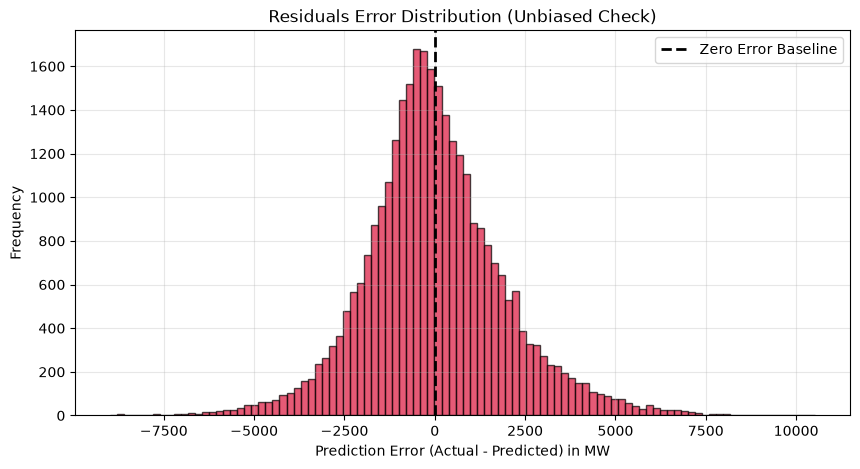

Mean Error Bias: -0.61 MW


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Load the data safely from disk
test_adv = pd.read_csv('test_with_predictions.csv', index_col=0, parse_dates=True)
TARGET = 'PJME_MW'

# 2. Calculate Evaluation Metrics for XGBoost Advanced
rmse_val = root_mean_squared_error(test_adv[TARGET], test_adv['xgb_advanced_pred'])
mae_val = mean_absolute_error(test_adv[TARGET], test_adv['xgb_advanced_pred'])
mape_val = mean_absolute_percentage_error(test_adv[TARGET], test_adv['xgb_advanced_pred']) * 100

print("--- Advanced XGBoost Performance Summary ---")
print(f"RMSE: {rmse_val:.2f} MW")
print(f"MAE:  {mae_val:.2f} MW")
print(f"MAPE: {mape_val:.2f}%")
print("--------------------------------------------")

# 3. Plot the Residual Distribution to check for bias
test_adv['residuals'] = test_adv[TARGET] - test_adv['xgb_advanced_pred']

plt.figure(figsize=(10, 5))
plt.hist(test_adv['residuals'], bins=100, color='crimson', edgecolor='k', alpha=0.7)
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Error Baseline')
plt.title('Residuals Error Distribution (Unbiased Check)')
plt.xlabel('Prediction Error (Actual - Predicted) in MW')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean Error Bias: {test_adv['residuals'].mean():.2f} MW")